In [2]:
from pathlib import Path
import os

DATAPATH = Path("./ebola_data").resolve()
os.environ["DATAPATH"] = str(DATAPATH)
print(f"DATAPATH set to: {DATAPATH}")

DATAPATH set to: /home/dmoi/projects/ESM3di/ebola_data/ebola_data


In [3]:
mamba install -c bioconda cd-hit

Using Cached Shard Index for bioconda/linux-64                                                      ✔ Done
Using Cached Shard Index for bioconda/noarch                                                        ✔ Done
Fetching and Parsing Packages' Shards                                                     ✔ Done (0.0 sec)
Using Cached Shard Index for conda-forge/linux-64                                                   ✔ Done
Using Cached Shard Index for conda-forge/noarch                                                     ✔ Done
Fetching and Parsing Packages' Shards                                                     ✔ Done (1.5 sec)
Using Cached Shard Index for bioconda/linux-64                                                      ✔ Done
Using Cached Shard Index for bioconda/noarch                                                        ✔ Done
Fetching and Parsing Packages' Shards                                                     ✔ Done (0.0 sec)
Using Cached Shard Index for conda-fo

In [4]:
# loop over all fasta files in the data directory and run cd-hit to cluster sequences at 90% identity
for fasta_file in DATAPATH.glob("*.fasta"):
	output_file = fasta_file.with_name(f"{fasta_file.stem}_cdhit.fasta")
	os.system(f"cd-hit -i {fasta_file} -o {output_file} -c 0.9 -n 5")

Program: CD-HIT, V4.8.1 (+OpenMP), Apr 24 2025, 22:00:32
Command: cd-hit -i
         /home/dmoi/projects/ESM3di/ebola_data/ebola_data/Ebola_GP.fasta
         -o
         /home/dmoi/projects/ESM3di/ebola_data/ebola_data/Ebola_GP_cdhit.fasta
         -c 0.9 -n 5

Started: Mon Jul  6 11:10:27 2026
                            Output                              
----------------------------------------------------------------
total seq: 2941
longest and shortest : 688 and 596
Total letters: 1986649
Sequences have been sorted



Approximated minimal memory consumption:
Sequence        : 2M
Buffer          : 1 X 16M = 16M
Table           : 1 X 65M = 65M
Miscellaneous   : 0M
Total           : 83M

Table limit with the given memory limit:
Max number of representatives: 921900
Max number of word counting entries: 89503665

comparing sequences from          0  to       2941
..
     2941  finished         74  clusters

Approximated maximum memory consumption: 84M
writing new database
writing clustering information
program completed !

Total CPU time 0.77
Program: CD-HIT, V4.8.1 (+OpenMP), Apr 24 2025, 22:00:32
Command: cd-hit -i
         /home/dmoi/projects/ESM3di/ebola_data/ebola_data/Ebola_NP.fasta
         -o
         /home/dmoi/projects/ESM3di/ebola_data/ebola_data/Ebola_NP_cdhit.fasta
         -c 0.9 -n 5

Started: Mon Jul  6 11:10:28 2026
                            Output                              
----------------------------------------------------------------
total seq: 3461
longest and shortest : 749 

In [ ]:
%%bash
set -euo pipefail

MODEL_CKPT="../checkpoints/esm3di_from_mlm/epoch_5.pt"
INPUT_DIR="$DATAPATH/"
OUTPUT_ROOT="$DATAPATH/ebola_protfams"

mkdir -p "$OUTPUT_ROOT"

find "$INPUT_DIR" -maxdepth 1 -type f \( -name "*.fa" -o -name "*.fasta" -o -name "*.faa" \) | while read -r aa_fasta; do
	fname="$(basename "$aa_fasta")"
	stem="${fname%.*}"
	out_dir="$OUTPUT_ROOT/$stem"
	mkdir -p "$out_dir"

	db_name="${stem}_foldseekdb"
	output_db="$out_dir/$db_name"

	python -m esm3di.fastas2foldseekdb \
		--aa-fasta "$aa_fasta" \
		--model-ckpt "$MODEL_CKPT" \
		--output-db "$output_db" \
		--keep-fastas
done

Checking for FoldSeek installation...
✓ FoldSeek found

Running ESM inference on /home/dmoi/projects/ESM3di/ebola_data/ebola_data/Ebola_GP.fasta...
Using model: ../checkpoints/esm3di_from_mlm/epoch_5.pt
Device: cuda
Loading model configuration from checkpoint...
Using 2 GPU(s) for inference on 2941 sequences


Multi-GPU inference:   0%|          | 0/2 [00:08<?, ?GPU/s]


Falling back to single-GPU inference...
Using single GPU: cuda
Initializing ESM3DiModel with Synthyra/ESMplusplus_small...

Loading model: Synthyra/ESMplusplus_small
Attention backend: config='sdpa' -> resolved='sdpa'


Some weights of ESMplusplusForTokenClassification were not initialized from the model checkpoint at Synthyra/ESMplusplus_small and are newly initialized: ['classifier.0.bias', 'classifier.0.weight', 'classifier.2.bias', 'classifier.2.weight', 'classifier.3.bias', 'classifier.3.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


✓ Base model loaded (TokenClassification)

Auto-discovering LoRA target modules...
Discovering LoRA target modules...
Discovered target modules: ['classifier.0', 'classifier.3', 'embed', 'sequence_head.0', 'sequence_head.3', 'transformer.blocks.0.attn.layernorm_qkv.1', 'transformer.blocks.0.attn.out_proj', 'transformer.blocks.0.ffn.1', 'transformer.blocks.0.ffn.3', 'transformer.blocks.1.attn.layernorm_qkv.1', 'transformer.blocks.1.attn.out_proj', 'transformer.blocks.1.ffn.1', 'transformer.blocks.1.ffn.3', 'transformer.blocks.10.attn.layernorm_qkv.1', 'transformer.blocks.10.attn.out_proj', 'transformer.blocks.10.ffn.1', 'transformer.blocks.10.ffn.3', 'transformer.blocks.11.attn.layernorm_qkv.1', 'transformer.blocks.11.attn.out_proj', 'transformer.blocks.11.ffn.1', 'transformer.blocks.11.ffn.3', 'transformer.blocks.12.attn.layernorm_qkv.1', 'transformer.blocks.12.attn.out_proj', 'transformer.blocks.12.ffn.1', 'transformer.blocks.12.ffn.3', 'transformer.blocks.13.attn.layernorm_qkv.1', 't

...

Falling back to single-GPU inference...
Using single GPU: cuda
Initializing ESM3DiModel with Synthyra/ESMplusplus_small...

Loading model: Synthyra/ESMplusplus_small
Attention backend: config='sdpa' -> resolved='sdpa'


Some weights of ESMplusplusForTokenClassification were not initialized from the model checkpoint at Synthyra/ESMplusplus_small and are newly initialized: ['classifier.0.bias', 'classifier.0.weight', 'classifier.2.bias', 'classifier.2.weight', 'classifier.3.bias', 'classifier.3.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


✓ Base model loaded (TokenClassification)

Auto-discovering LoRA target modules...
Discovering LoRA target modules...
Discovered target modules: ['classifier.0', 'classifier.3', 'embed', 'sequence_head.0', 'sequence_head.3', 'transformer.blocks.0.attn.layernorm_qkv.1', 'transformer.blocks.0.attn.out_proj', 'transformer.blocks.0.ffn.1', 'transformer.blocks.0.ffn.3', 'transformer.blocks.1.attn.layernorm_qkv.1', 'transformer.blocks.1.attn.out_proj', 'transformer.blocks.1.ffn.1', 'transformer.blocks.1.ffn.3', 'transformer.blocks.10.attn.layernorm_qkv.1', 'transformer.blocks.10.attn.out_proj', 'transformer.blocks.10.ffn.1', 'transformer.blocks.10.ffn.3', 'transformer.blocks.11.attn.layernorm_qkv.1', 'transformer.blocks.11.attn.out_proj', 'transformer.blocks.11.ffn.1', 'transformer.blocks.11.ffn.3', 'transformer.blocks.12.attn.layernorm_qkv.1', 'transformer.blocks.12.attn.out_proj', 'transformer.blocks.12.ffn.1', 'transformer.blocks.12.ffn.3', 'transformer.blocks.13.attn.layernorm_qkv.1', 't

Asking to truncate to max_length but no maximum length is provided and the model has no predefined maximum length. Default to no truncation.


Processed 40/3648 sequences
Processed 80/3648 sequences
Processed 120/3648 sequences
Processed 160/3648 sequences
Processed 200/3648 sequences
Processed 240/3648 sequences
Processed 280/3648 sequences
Processed 320/3648 sequences
Processed 360/3648 sequences
Processed 400/3648 sequences
Processed 440/3648 sequences
Processed 480/3648 sequences
Processed 520/3648 sequences
Processed 560/3648 sequences
Processed 600/3648 sequences
Processed 640/3648 sequences
Processed 680/3648 sequences
Processed 720/3648 sequences
Processed 760/3648 sequences
Processed 800/3648 sequences
Processed 840/3648 sequences
Processed 880/3648 sequences
Processed 920/3648 sequences
Processed 960/3648 sequences
Processed 1000/3648 sequences
Processed 1040/3648 sequences
Processed 1080/3648 sequences
Processed 1120/3648 sequences
Processed 1160/3648 sequences
Processed 1200/3648 sequences
Processed 1240/3648 sequences
Processed 1280/3648 sequences
Processed 1320/3648 sequences
Processed 1360/3648 sequences
Proces

In [ ]:
#run 3di prediction on the clustered fasta files

In [99]:
%%bash
set -euo pipefail

MODEL_CKPT="../checkpoints/esm3di_from_mlm/epoch_5.pt"
INPUT_DIR="$DATAPATH/"
OUTPUT_ROOT="$DATAPATH/ebola_protfams_cdhit"

mkdir -p "$OUTPUT_ROOT"

find "$INPUT_DIR" -maxdepth 1 -type f \( -name "*_cdhit.fasta" \) | while read -r aa_fasta; do
	fname="$(basename "$aa_fasta")"
	stem="${fname%.*}"
	out_dir="$OUTPUT_ROOT/$stem"
	mkdir -p "$out_dir"

	db_name="${stem}_foldseekdb"
	output_db="$out_dir/$db_name"

	python -m esm3di.fastas2foldseekdb \
		--aa-fasta "$aa_fasta" \
		--model-ckpt "$MODEL_CKPT" \
		--output-db "$output_db" \
		--keep-fastas
done

Checking for FoldSeek installation...
✓ FoldSeek found

Running ESM inference on /home/dmoi/projects/ESM3di/ebola_data/ebola_data/Ebola_GP_cdhit.fasta...
Using model: ../checkpoints/esm3di_from_mlm/epoch_5.pt
Device: cuda
Loading model configuration from checkpoint...
Using 2 GPU(s) for inference on 74 sequences


Multi-GPU inference:   0%|          | 0/2 [00:05<?, ?GPU/s]


Falling back to single-GPU inference...
Using single GPU: cuda
Initializing ESM3DiModel with Synthyra/ESMplusplus_small...

Loading model: Synthyra/ESMplusplus_small
Attention backend: config='sdpa' -> resolved='sdpa'


Some weights of ESMplusplusForTokenClassification were not initialized from the model checkpoint at Synthyra/ESMplusplus_small and are newly initialized: ['classifier.0.bias', 'classifier.0.weight', 'classifier.2.bias', 'classifier.2.weight', 'classifier.3.bias', 'classifier.3.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


✓ Base model loaded (TokenClassification)

Auto-discovering LoRA target modules...
Discovering LoRA target modules...
Discovered target modules: ['classifier.0', 'classifier.3', 'embed', 'sequence_head.0', 'sequence_head.3', 'transformer.blocks.0.attn.layernorm_qkv.1', 'transformer.blocks.0.attn.out_proj', 'transformer.blocks.0.ffn.1', 'transformer.blocks.0.ffn.3', 'transformer.blocks.1.attn.layernorm_qkv.1', 'transformer.blocks.1.attn.out_proj', 'transformer.blocks.1.ffn.1', 'transformer.blocks.1.ffn.3', 'transformer.blocks.10.attn.layernorm_qkv.1', 'transformer.blocks.10.attn.out_proj', 'transformer.blocks.10.ffn.1', 'transformer.blocks.10.ffn.3', 'transformer.blocks.11.attn.layernorm_qkv.1', 'transformer.blocks.11.attn.out_proj', 'transformer.blocks.11.ffn.1', 'transformer.blocks.11.ffn.3', 'transformer.blocks.12.attn.layernorm_qkv.1', 'transformer.blocks.12.attn.out_proj', 'transformer.blocks.12.ffn.1', 'transformer.blocks.12.ffn.3', 'transformer.blocks.13.attn.layernorm_qkv.1', 't

...

Falling back to single-GPU inference...
Using single GPU: cuda
Initializing ESM3DiModel with Synthyra/ESMplusplus_small...

Loading model: Synthyra/ESMplusplus_small
Attention backend: config='sdpa' -> resolved='sdpa'


Some weights of ESMplusplusForTokenClassification were not initialized from the model checkpoint at Synthyra/ESMplusplus_small and are newly initialized: ['classifier.0.bias', 'classifier.0.weight', 'classifier.2.bias', 'classifier.2.weight', 'classifier.3.bias', 'classifier.3.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


✓ Base model loaded (TokenClassification)

Auto-discovering LoRA target modules...
Discovering LoRA target modules...
Discovered target modules: ['classifier.0', 'classifier.3', 'embed', 'sequence_head.0', 'sequence_head.3', 'transformer.blocks.0.attn.layernorm_qkv.1', 'transformer.blocks.0.attn.out_proj', 'transformer.blocks.0.ffn.1', 'transformer.blocks.0.ffn.3', 'transformer.blocks.1.attn.layernorm_qkv.1', 'transformer.blocks.1.attn.out_proj', 'transformer.blocks.1.ffn.1', 'transformer.blocks.1.ffn.3', 'transformer.blocks.10.attn.layernorm_qkv.1', 'transformer.blocks.10.attn.out_proj', 'transformer.blocks.10.ffn.1', 'transformer.blocks.10.ffn.3', 'transformer.blocks.11.attn.layernorm_qkv.1', 'transformer.blocks.11.attn.out_proj', 'transformer.blocks.11.ffn.1', 'transformer.blocks.11.ffn.3', 'transformer.blocks.12.attn.layernorm_qkv.1', 'transformer.blocks.12.attn.out_proj', 'transformer.blocks.12.ffn.1', 'transformer.blocks.12.ffn.3', 'transformer.blocks.13.attn.layernorm_qkv.1', 't

Asking to truncate to max_length but no maximum length is provided and the model has no predefined maximum length. Default to no truncation.


Processed 40/108 sequences
Processed 80/108 sequences
Processed 108/108 sequences
Writing predictions to: /home/dmoi/projects/ESM3di/ebola_data/ebola_data/ebola_protfams_cdhit/Ebola_L_cdhit/Ebola_L_cdhit_foldseekdb_3di.fasta
✓ Prediction complete! 108 sequences written to /home/dmoi/projects/ESM3di/ebola_data/ebola_data/ebola_protfams_cdhit/Ebola_L_cdhit/Ebola_L_cdhit_foldseekdb_3di.fasta
✓ FASTA files ready

Creating FoldSeek database: /home/dmoi/projects/ESM3di/ebola_data/ebola_data/ebola_protfams_cdhit/Ebola_L_cdhit/Ebola_L_cdhit_foldseekdb
Finished writing Foldseek database to /home/dmoi/projects/ESM3di/ebola_data/ebola_data/ebola_protfams_cdhit/Ebola_L_cdhit/Ebola_L_cdhit_foldseekdb
Total sequences: 108
Pep file: /home/dmoi/projects/ESM3di/ebola_data/ebola_data/ebola_protfams_cdhit/Ebola_L_cdhit/Ebola_L_cdhit_foldseekdb, size: 235927 bytes
TDI file: /home/dmoi/projects/ESM3di/ebola_data/ebola_data/ebola_protfams_cdhit/Ebola_L_cdhit/Ebola_L_cdhit_foldseekdb_ss, size: 235927 bytes
H

In [ ]:
import glob
#check if the output files exist
output_files = glob.glob(f"{DATAPATH}/ebola_protfams/*/*.index")
if len(output_files) == 0:
	raise FileNotFoundError("No output .index files were created. Please check the previous steps for errors.")

In [ ]:
conda install -c bioconda foldtree

Retrieving notices: done
Channels:
 - bioconda
 - conda-forge
Platform: linux-64
Solving environment: done


==> WARNING: A newer version of conda exists. <==
    current version: 26.1.0
    latest version: 26.5.3

Please update conda by running

    $ conda update -n base -c conda-forge conda



## Package Plan ##

  environment location: /home/dmoi/miniforge3/envs/fastas2foldseekdb

  added / updated specs:
    - foldtree


The following packages will be downloaded:

    package                    |            build
    ---------------------------|-----------------
    amply-0.1.7                |     pyhd8ed1ab_0          26 KB  conda-forge
    attrs-26.1.0               |     pyhcf101f3_0          63 KB  conda-forge
    backports.zstd-1.6.0       |  py310h69bd2ac_0         188 KB  conda-forge
    biopython-1.87             |  py310h7c4b9e2_0         2.6 MB  conda-forge
    ca-certificates-2026.6.17  |       hbd8a1cb_0         126 KB  conda-forge
    certifi-2026.6.17          |    

In [9]:
#create a foldtree for each family

import os
import glob
import subprocess

def runFoldseek_allvall( dbpath , outfolder , foldseekpath = 'foldseek' , maxseqs = 3000):
	'''
	run foldseek search and createtsv
	
	parameters
	----------
	dbpath : str
		path to foldseek database
	outfolder : str 
		path to output folder
	maxseqs : int   
		maximum number of sequences to compare to

	'''
	if not os.path.exists(outfolder):
		os.makedirs(outfolder)
	dbfolder = os.path.dirname(dbpath)

	cmd = foldseekpath + " easy-search " + dbpath + " "+ dbpath +" "+ outfolder+"/allvall.csv " +  dbfolder+"/tmp --format-output 'query,target,fident,alnlen,mismatch,gapopen,qstart,qend,tstart,tend,evalue,bits' --exhaustive-search --alignment-type 2" 
	subprocess.run(cmd, shell=True, check=True)
	
	return outfolder +'aln_score.tsv'

protfam_folders = glob.glob(f"{DATAPATH}/ebola_protfams/*") + glob.glob(f"{DATAPATH}/ebola_protfams_cdhit/*")
for folder in protfam_folders:
	db_files = glob.glob(f"{folder}/*.index")
	if len(db_files) == 0:
		print(f"No .index files found in {folder}. Skipping.")
		continue

	db_path = db_files[0].replace('.index', '')  # Assuming there's only one .index file per folder
	db_path = db_path.replace('_h', '')  # Ensure the path uses forward slashes
	db_path = db_path.replace('_ss', '')  # Ensure the path uses forward slashes
	
	output_folder = os.path.join(folder, "foldseek_results")
	print(f"Running foldseek for {db_path}...")
	if not os.path.exists(os.path.join(output_folder, "allvall.csv")):  # Check if results already exist	
		runFoldseek_allvall(db_path, output_folder)
		print(f"Results saved in {output_folder}.")
	else:
		print(f"Results already exist in {output_folder}. Skipping foldseek run.")


Running foldseek for /home/dmoi/projects/ESM3di/ebola_data/ebola_data/ebola_protfams/Ebola_GP/Ebola_GP_foldseekdb...
Results already exist in /home/dmoi/projects/ESM3di/ebola_data/ebola_data/ebola_protfams/Ebola_GP/foldseek_results. Skipping foldseek run.
Running foldseek for /home/dmoi/projects/ESM3di/ebola_data/ebola_data/ebola_protfams/Ebola_GP_cdhit/Ebola_GP_cdhit_foldseekdb...
Results already exist in /home/dmoi/projects/ESM3di/ebola_data/ebola_data/ebola_protfams/Ebola_GP_cdhit/foldseek_results. Skipping foldseek run.
Running foldseek for /home/dmoi/projects/ESM3di/ebola_data/ebola_data/ebola_protfams/Ebola_NP/Ebola_NP_foldseekdb...
Results already exist in /home/dmoi/projects/ESM3di/ebola_data/ebola_data/ebola_protfams/Ebola_NP/foldseek_results. Skipping foldseek run.
Running foldseek for /home/dmoi/projects/ESM3di/ebola_data/ebola_data/ebola_protfams/Ebola_L/Ebola_L_foldseekdb...
Results already exist in /home/dmoi/projects/ESM3di/ebola_data/ebola_data/ebola_protfams/Ebola_L/fo

In [11]:
import shlex
def runQuicktree(   clusterfile , quicktreepath= 'quicktree' ):
	'''
	run quicktree

	parameters
	----------
	clusterfile : str
		path to all vs all distance matrix in fastme format
	quicktreepath : str 
		path to quicktree binary

	'''
	args = quicktreepath + ' -i m ' + clusterfile +' > ' + clusterfile + '.struct_tree.nwk'
	print(args)
	p =subprocess.run(args , shell= True)
	return clusterfile + '.struct_tree.nwk'


def runFastme(   clusterfile , fastmepath= 'fastme' ):
	'''
	run fastme

	parameters
	----------
	clusterfile : str
		path to all vs all distance matrix in fastme format
	fastmepath : str 
		path to fastme binary

	'''
	args = fastmepath + ' -i ' + clusterfile +' -o ' + clusterfile + '.struct_tree.nwk'
	print(args)
	p =subprocess.run(args , shell= True)
	return clusterfile + '.struct_tree.nwk'


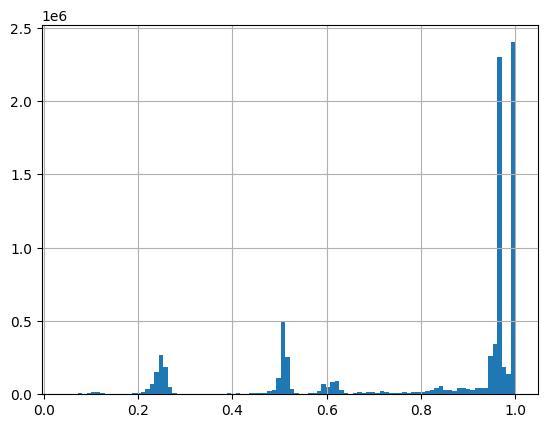

              query          target  fident  alnlen  mismatch  gapopen  \
0        ABE27043.1      ABE27015.1   1.000     681         0        0   
1        ABE27043.1      ABE27022.1   1.000     681         0        0   
2        ABE27043.1      ABE27029.1   1.000     681         0        0   
3        ABE27043.1      ABE27036.1   1.000     681         0        0   
5        ABE27043.1      ABE27050.1   1.000     681         0        0   
...             ...             ...     ...     ...       ...      ...   
8643335  AKC36787.1      UCU83238.1   0.094     236       197        0   
8643336  AKC36787.1  YP_010800908.1   0.094     236       197        0   
8643337  AKC36787.1      QGM12360.2   0.099     369       299        0   
8643338  AKC36787.1      QGM12360.2   0.099     369       299        0   
8643339  AKC36787.1  YP_010800198.1   0.099     369       299        0   

         qstart  qend  tstart  tend         evalue  bits  
0             1   681       1   681  4.384000e-103  

100%|██████████| 8640255/8640255 [08:42<00:00, 16534.04it/s]


[[0.00000000e+00 3.56756071e-02 7.34866723e-01 ... 1.00000538e-05
  4.92830530e-02 1.00000538e-05]
 [3.56756071e-02 0.00000000e+00 7.23912533e-01 ... 3.56756071e-02
  1.41064460e-02 3.56756071e-02]
 [7.34866723e-01 7.23912533e-01 0.00000000e+00 ... 7.34866723e-01
  7.70813227e-01 7.34866723e-01]
 ...
 [1.00000538e-05 3.56756071e-02 7.34866723e-01 ... 0.00000000e+00
  4.92830530e-02 1.00000538e-05]
 [4.92830530e-02 1.41064460e-02 7.70813227e-01 ... 4.92830530e-02
  0.00000000e+00 4.92830530e-02]
 [1.00000538e-05 3.56756071e-02 7.34866723e-01 ... 1.00000538e-05
  4.92830530e-02 0.00000000e+00]] 215.89018894101406 0.0
quicktree -i m /home/dmoi/projects/ESM3di/ebola_data/ebola_data/ebola_protfams/Ebola_GP/fident_distmat.txt > /home/dmoi/projects/ESM3di/ebola_data/ebola_data/ebola_protfams/Ebola_GP/fident_distmat.txt.struct_tree.nwk


⚠️ toytree | writer:write | Deprecated args to write(): ['tree_format']. See docs.


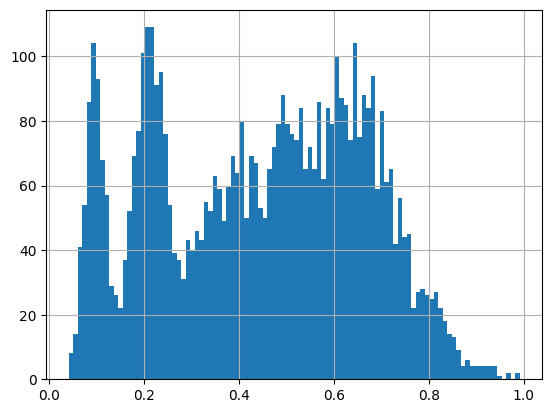

           query      target  fident  alnlen  mismatch  gapopen  qstart  qend  \
1     QNL26815.1  AYP10418.1   0.744     676       173        0       1   676   
2     QNL26815.1  QNL27238.1   0.690     676       209        0       1   676   
3     QNL26815.1  QNL28317.1   0.771     676       155        0       1   676   
4     QNL26815.1  QNL27166.1   0.758     676       163        0       1   676   
5     QNL26815.1  QNL25078.1   0.845     607        94        0       1   607   
...          ...         ...     ...     ...       ...      ...     ...   ...   
5306  QNL24358.1  QGM12357.2   0.106     268       235        0     105   368   
5307  QNL24358.1  AVM87245.1   0.084     315       266        0     105   395   
5308  QNL24358.1  WBV79888.1   0.099     282       236        0     106   368   
5309  QNL24358.1  UCU83238.1   0.088     232       202        0     136   367   
5310  QNL24358.1  QGM12360.2   0.093     334       261        0     106   394   

      tstart  tend        e

100%|██████████| 5237/5237 [00:01<00:00, 3204.61it/s]
⚠️ toytree | writer:write | Deprecated args to write(): ['tree_format']. See docs.


[[0.         0.64362742 0.49784448 ... 2.0023393  0.42953426 0.33959822]
 [0.64362742 0.         1.11139849 ... 2.04191948 0.91551053 0.54604179]
 [0.49784448 1.11139849 0.         ... 1.73479529 0.28300547 0.68134217]
 ...
 [2.0023393  2.04191948 1.73479529 ... 0.         1.49928062 1.67538014]
 [0.42953426 0.91551053 0.28300547 ... 1.49928062 0.         0.50728618]
 [0.33959822 0.54604179 0.68134217 ... 1.67538014 0.50728618 0.        ]] 215.89018894101406 0.0
quicktree -i m /home/dmoi/projects/ESM3di/ebola_data/ebola_data/ebola_protfams/Ebola_GP_cdhit/fident_distmat.txt > /home/dmoi/projects/ESM3di/ebola_data/ebola_data/ebola_protfams/Ebola_GP_cdhit/fident_distmat.txt.struct_tree.nwk


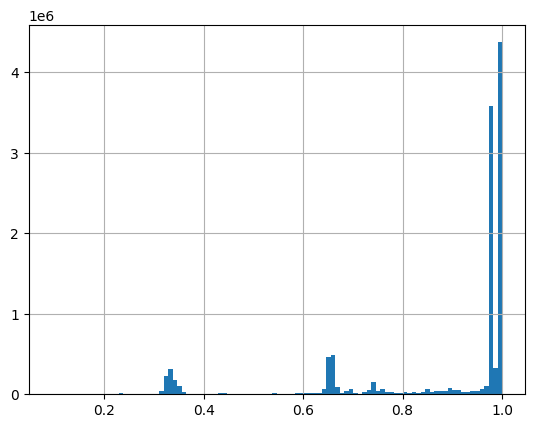

               query          target  fident  alnlen  mismatch  gapopen  \
0         QYR86591.1      QNL24922.1   1.000     739         0        0   
1         QYR86591.1      QNL24940.1   1.000     739         0        0   
2         QYR86591.1      QNL24949.1   1.000     739         0        0   
3         QYR86591.1      QNL24994.1   1.000     739         0        0   
4         QYR86591.1      QNL25003.1   1.000     739         0        0   
...              ...             ...     ...     ...       ...      ...   
11978492  APT69610.1  YP_010798906.1   0.227     695       494        0   
11978493  APT69610.1      QNL24724.1   0.292     614       434        0   
11978494  APT69610.1      AVM87232.1   0.173     719       496        0   
11978495  APT69610.1      AVM87232.1   0.173     719       496        0   
11978496  APT69610.1  YP_010085036.1   0.173     719       496        0   

          qstart  qend  tstart  tend         evalue  bits  
0              1   739       1   739  7

100%|██████████| 11974866/11974866 [11:40<00:00, 17091.17it/s]


[[0.00000000e+00 1.00000538e-05 1.00000538e-05 ... 2.12407275e-02
  1.00000538e-05 2.43151105e-02]
 [1.00000538e-05 0.00000000e+00 1.00000538e-05 ... 2.12407275e-02
  1.00000538e-05 2.43151105e-02]
 [1.00000538e-05 1.00000538e-05 0.00000000e+00 ... 2.12407275e-02
  1.00000538e-05 2.43151105e-02]
 ...
 [2.12407275e-02 2.12407275e-02 2.12407275e-02 ... 0.00000000e+00
  2.12407275e-02 3.00484914e-03]
 [1.00000538e-05 1.00000538e-05 1.00000538e-05 ... 2.12407275e-02
  0.00000000e+00 2.43151105e-02]
 [2.43151105e-02 2.43151105e-02 2.43151105e-02 ... 3.00484914e-03
  2.43151105e-02 0.00000000e+00]] 215.89018894101406 0.0
quicktree -i m /home/dmoi/projects/ESM3di/ebola_data/ebola_data/ebola_protfams/Ebola_NP/fident_distmat.txt > /home/dmoi/projects/ESM3di/ebola_data/ebola_data/ebola_protfams/Ebola_NP/fident_distmat.txt.struct_tree.nwk


⚠️ toytree | writer:write | Deprecated args to write(): ['tree_format']. See docs.


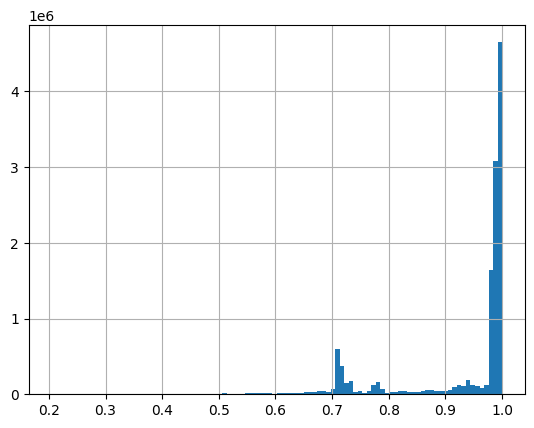

               query      target  fident  alnlen  mismatch  gapopen  qstart  \
0         AKG95592.1  AIE11805.1   1.000    2212         0        0       1   
1         AKG95592.1  AIE11814.1   1.000    2212         0        0       1   
2         AKG95592.1  AIE11823.1   1.000    2212         0        0       1   
3         AKG95592.1  AIE11832.1   1.000    2212         0        0       1   
4         AKG95592.1  AIE11841.1   1.000    2212         0        0       1   
...              ...         ...     ...     ...       ...      ...     ...   
13307899  AQA27505.1  QYR86248.1   0.513    1893       921        0       1   
13307900  AQA27505.1  QYR86851.1   0.421    2188      1266        0       1   
13307901  AQA27505.1  QYR86869.1   0.335    2180      1449        0       1   
13307902  AQA27505.1  QYR86185.1   0.349    2205      1435        0       1   
13307903  AQA27505.1  QYR86194.1   0.294    1953      1378        0       1   

          qend  tstart  tend        evalue   bits  

100%|██████████| 13304164/13304164 [12:42<00:00, 17437.88it/s]


[[0.         0.13077895 0.13077895 ... 0.13077895 0.13135462 0.13250704]
 [0.13077895 0.         0.00100054 ... 0.00100054 0.00100054 0.00200215]
 [0.13077895 0.00100054 0.         ... 0.00100054 0.00100054 0.00200215]
 ...
 [0.13077895 0.00100054 0.00100054 ... 0.         0.00100054 0.00200215]
 [0.13135462 0.00100054 0.00100054 ... 0.00100054 0.         0.00100054]
 [0.13250704 0.00200215 0.00200215 ... 0.00200215 0.00100054 0.        ]] 1.6937359956410714 0.0
quicktree -i m /home/dmoi/projects/ESM3di/ebola_data/ebola_data/ebola_protfams/Ebola_L/fident_distmat.txt > /home/dmoi/projects/ESM3di/ebola_data/ebola_data/ebola_protfams/Ebola_L/fident_distmat.txt.struct_tree.nwk


⚠️ toytree | writer:write | Deprecated args to write(): ['tree_format']. See docs.


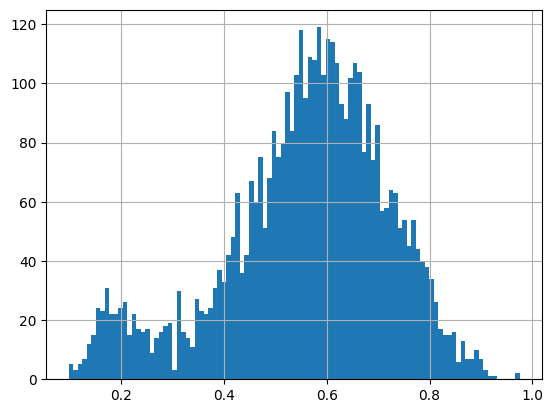

           query          target  fident  alnlen  mismatch  gapopen  qstart  \
1     AZL57167.1      QNL24499.1   0.812     714       134        0       2   
2     AZL57167.1      AAA42977.1   0.725     714       196        0       2   
3     AZL57167.1      QNL28314.1   0.724     714       197        0       2   
4     AZL57167.1      QNL24148.1   0.740     714       185        0       2   
5     AZL57167.1      QNL27730.1   0.713     714       205        0       2   
...          ...             ...     ...     ...       ...      ...     ...   
4349  QNL27262.1      QYR86114.1   0.306     425       294        0     271   
4350  QNL27262.1      AER23671.1   0.251     447       325        0     272   
4351  QNL27262.1      AAA46563.1   0.201     436       326        0     272   
4352  QNL27262.1  YP_010798906.1   0.203     279       208        0     274   
4353  QNL27262.1      AVM87232.1   0.142     207       157        0     349   

      qend  tstart  tend        evalue  bits  
1   

100%|██████████| 4288/4288 [00:02<00:00, 1897.65it/s]
⚠️ toytree | writer:write | Deprecated args to write(): ['tree_format']. See docs.


[[0.         0.51160976 0.84840792 ... 0.5817978  0.67822659 1.42928651]
 [0.51160976 0.         0.39602414 ... 0.23995756 0.7120101  0.9806302 ]
 [0.84840792 0.39602414 0.         ... 0.4263656  0.52382382 1.12638538]
 ...
 [0.5817978  0.23995756 0.4263656  ... 0.         0.50556237 0.98494575]
 [0.67822659 0.7120101  0.52382382 ... 0.50556237 0.         1.60819237]
 [1.42928651 0.9806302  1.12638538 ... 0.98494575 1.60819237 0.        ]] 8.268225519553418 0.0
quicktree -i m /home/dmoi/projects/ESM3di/ebola_data/ebola_data/ebola_protfams_cdhit/Ebola_NP_cdhit/fident_distmat.txt > /home/dmoi/projects/ESM3di/ebola_data/ebola_data/ebola_protfams_cdhit/Ebola_NP_cdhit/fident_distmat.txt.struct_tree.nwk


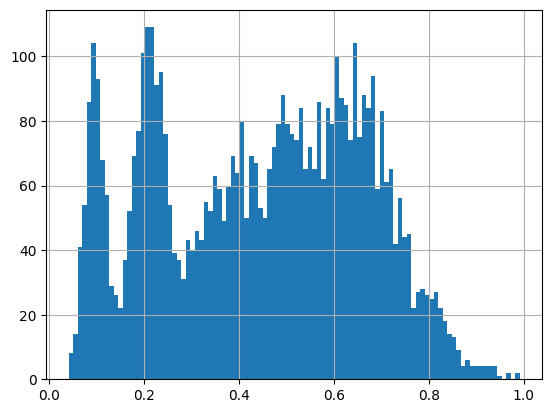

           query      target  fident  alnlen  mismatch  gapopen  qstart  qend  \
1     QNL28434.1  QNL24160.1   0.608     658       258        0       1   658   
2     QNL28434.1  QNL28317.1   0.705     676       199        0       1   676   
3     QNL28434.1  QNL27823.1   0.693     577       177        0       7   583   
4     QNL28434.1  QNL26815.1   0.683     676       214        0       1   676   
5     QNL28434.1  AYP10418.1   0.618     676       258        0       1   676   
...          ...         ...     ...     ...       ...      ...     ...   ...   
5306  AYP10415.1  XJQ58955.1   0.304     554       280        0     120   673   
5307  AYP10415.1  CAA78117.1   0.461     181        89        0     507   673   
5308  AYP10415.1  UTU41908.1   0.236     354       269        0     320   673   
5309  AYP10415.1  QYR85550.1   0.491     675       343        0       1   675   
5310  AYP10415.1  AAC40459.1   0.237     354       250        0     320   673   

      tstart  tend        e

100%|██████████| 5237/5237 [00:00<00:00, 16571.66it/s]
⚠️ toytree | writer:write | Deprecated args to write(): ['tree_format']. See docs.


[[0.         0.64362742 0.49784448 ... 2.0023393  0.42953426 0.33959822]
 [0.64362742 0.         1.11139849 ... 2.04191948 0.91551053 0.54604179]
 [0.49784448 1.11139849 0.         ... 1.73479529 0.28300547 0.68134217]
 ...
 [2.0023393  2.04191948 1.73479529 ... 0.         1.49928062 1.67538014]
 [0.42953426 0.91551053 0.28300547 ... 1.49928062 0.         0.50728618]
 [0.33959822 0.54604179 0.68134217 ... 1.67538014 0.50728618 0.        ]] 215.89018894101406 0.0
quicktree -i m /home/dmoi/projects/ESM3di/ebola_data/ebola_data/ebola_protfams_cdhit/Ebola_GP_cdhit/fident_distmat.txt > /home/dmoi/projects/ESM3di/ebola_data/ebola_data/ebola_protfams_cdhit/Ebola_GP_cdhit/fident_distmat.txt.struct_tree.nwk


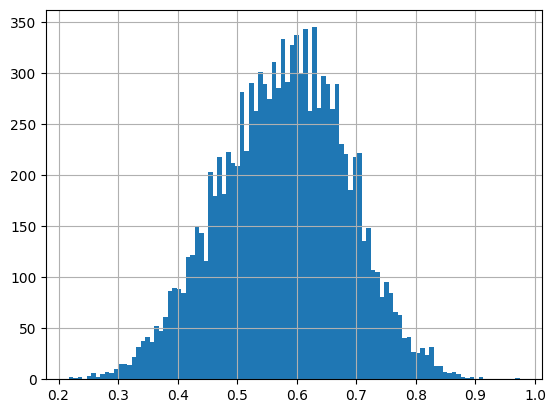

            query      target  fident  alnlen  mismatch  gapopen  qstart  \
1      QNL27324.1  QYR86032.1   0.871    2212       285        0       1   
2      QNL27324.1  QNL27504.1   0.823    2212       391        0       1   
3      QNL27324.1  QNL27306.1   0.806    2212       429        0       1   
4      QNL27324.1  AYA82998.1   0.821    2212       396        0       1   
5      QNL27324.1  QYR85393.1   0.818    2152       391        0       1   
...           ...         ...     ...     ...       ...      ...     ...   
11659  QYR86185.1  AJZ74533.1   0.306    1619      1123        0     271   
11660  QYR86185.1  WWV92810.1   0.357    1757      1129        0       9   
11661  QYR86185.1  QNL27270.1   0.365    1650      1033        0      52   
11662  QYR86185.1  QYR86869.1   0.465    1889      1010        0       1   
11663  QYR86185.1  QNC49574.1   0.471     240       126        0     757   

       qend  tstart  tend        evalue   bits  
1      2212       1  2212  0.000000e+0

100%|██████████| 11556/11556 [00:00<00:00, 16477.69it/s]
⚠️ toytree | writer:write | Deprecated args to write(): ['tree_format']. See docs.


[[0.         0.64063546 0.69602117 ... 0.84965373 0.61026941 0.56696199]
 [0.64063546 0.         0.60450493 ... 0.61123364 0.43032811 0.64763173]
 [0.69602117 0.60450493 0.         ... 0.89827554 0.54066087 0.68865271]
 ...
 [0.84965373 0.61123364 0.89827554 ... 0.         0.70238379 0.82020536]
 [0.61026941 0.43032811 0.54066087 ... 0.70238379 0.         0.49784448]
 [0.56696199 0.64763173 0.68865271 ... 0.82020536 0.49784448 0.        ]] 1.6138458870508834 0.0
quicktree -i m /home/dmoi/projects/ESM3di/ebola_data/ebola_data/ebola_protfams_cdhit/Ebola_L_cdhit/fident_distmat.txt > /home/dmoi/projects/ESM3di/ebola_data/ebola_data/ebola_protfams_cdhit/Ebola_L_cdhit/fident_distmat.txt.struct_tree.nwk


In [12]:
#finish up 
import sys
import pandas as pd
import numpy as np
import tqdm
from matplotlib import pyplot as plt

foldtree_dir = '/home/dmoi/projects/fold_tree'
fastmepath = 'fastme'
delta = 1e-5

sys.path.append(foldtree_dir)
import foldtree.foldseek2tree as ft1


for folder in protfam_folders:
	alnres = f"{folder}/foldseek_results/allvall.csv"
	res = pd.read_table(alnres , header = None )
	res[0] = res[0].map(lambda x :x.replace('.pdb', ''))
	res[1] = res[1].map(lambda x :x.replace('.pdb', ''))
	res.columns = 'query,target,fident,alnlen,mismatch,gapopen,qstart,qend,tstart,tend,evalue,bits'.split(',')
	#drop rows where query and target are the same
	res = res[res['query'] != res['target']]
	
	res.fident.hist(bins = 100)
	plt.show()
	ids = list( set(list(res['query'].unique()) + list(res['target'].unique())))
	pos = { protid : i for i,protid in enumerate(ids)}
	kernels = ['fident']
	matrices = { k:np.zeros((len(pos), len(pos))) for k in kernels }
	print(res)

	#calc kernel for tm, aln score, lddt
	for idx,row in tqdm.tqdm(res.iterrows(), total=res.shape[0]):
		for k in matrices:
			matrices[k][pos[row['query']] , pos[row['target']]] += row[k]
			matrices[k][pos[row['target']] , pos[row['query']]] += row[k]

	trees = {}
	for i,k in enumerate(matrices):
		matrices[k] /= 2
		matrices[k] = 1-matrices[k]
		matrices[k][np.diag_indices_from(matrices[k])] = 0
		#floor at 0.0001 to avoid issues with fastme
		matrices[k][matrices[k] < delta] = delta
		

		if k == 'fident':
			distmat = ft1.Tajima_dist( matrices[k] , bfactor = .93 , iter = 100 )
		else:
			distmat = ft1.Tajima_dist( matrices[k] )
		print(distmat,  np.amax(distmat), np.amin(distmat) )

		#save the distance matrix and run fastme to the same folder as the input csv file
		np.save( os.path.join(folder, k + '_distmat.npy') , distmat)
		distmat_txt = ft1.distmat_to_txt( ids , distmat , os.path.join(folder, k + '_distmat.txt') )
		treefile = runQuicktree( clusterfile=distmat_txt )	
		out_tree = ft1.postprocess(treefile, treefile+'.pp.nwk' , delta = delta)
		trees[k] = out_tree
		

In [29]:
import os
from typing import Dict, List, Optional

from Bio import Entrez

def _extract_tax_id_from_feature_table(feature_table: List[dict]) -> str:
    """Extract NCBI taxon ID from GenBank feature qualifiers."""
    for feature in feature_table or []:
        for qualifier in feature.get("GBFeature_quals", []) or []:
            if qualifier.get("GBQualifier_name") != "db_xref":
                continue
            value = qualifier.get("GBQualifier_value", "")
            if value.startswith("taxon:"):
                return value.split(":", 1)[1]
    return ""


def fetch_taxonomic_info(
    accessions: List[str],
    batch_size: int = 10,
    seq_type: str = "nucleotide",
    email: Optional[str] = None,
    api_key: Optional[str] = None,
) -> Dict[str, Dict]:
    """
    Fetch taxonomic information for a list of accessions using NCBI Entrez.
    
    Args:
        accessions: List of NCBI accession numbers
        batch_size: Number of accessions to fetch per batch (default: 10)
        seq_type: Type of sequence - "nucleotide" or "protein" (default: "nucleotide")
        email: Entrez contact email. Defaults to NCBI_EMAIL env var when omitted.
        api_key: NCBI API key. Defaults to NCBI_API_KEY env var when omitted.
        
    Returns:
        Dictionary with accession as key and taxonomic info as value
    """
    
    Entrez.email = email or os.environ.get("NCBI_EMAIL", "dmoi@unil.ch")
    Entrez.api_key = api_key or os.environ.get("NCBI_API_KEY")
    
    # Map sequence type to NCBI database
    db_map = {"nucleotide": "nucleotide", "protein": "protein"}
    db = db_map.get(seq_type.lower(), "nucleotide")
    
    taxonomic_info = {}
    
    # Process accessions in batches
    for i in tqdm.tqdm(range(0, len(accessions), batch_size)):
        batch = accessions[i:i + batch_size]
        
        try:
            # Accession identifiers belong to sequence DBs, not the taxonomy DB.
            accession_ids = ",".join(batch)
            handle = Entrez.efetch(db=db, id=accession_ids, rettype="gb", retmode="xml")
            records = Entrez.read(handle)
            handle.close()

            found = set()
            for record in records:
                acc_version = record.get("GBSeq_accession-version", "")
                primary = record.get("GBSeq_primary-accession", "")
                accession_key = acc_version or primary
                if not accession_key:
                    continue

                normalized_candidates = {accession_key, primary, accession_key.split(".")[0]}
                matched_accession = next((a for a in batch if a in normalized_candidates), accession_key)

                taxonomic_info[matched_accession] = {
                    "accession": accession_key,
                    "tax_id": _extract_tax_id_from_feature_table(record.get("GBSeq_feature-table", [])),
                    "organism": record.get("GBSeq_organism", ""),
                    "scientific_name": record.get("GBSeq_organism", ""),
                    "taxonomy": record.get("GBSeq_taxonomy", ""),
                    "lineage": record.get("GBSeq_taxonomy", ""),
                    "division": record.get("GBSeq_division", ""),
                }
                found.add(matched_accession)

            for accession in batch:
                if accession not in found and accession not in taxonomic_info:
                    taxonomic_info[accession] = {
                        "error": "No sequence record found for accession in requested DB",
                        "db": db,
                    }

        except Exception as e:
            for accession in batch:
                taxonomic_info[accession] = {"error": str(e)}
    
    return taxonomic_info


# Example usage:
if __name__ == "__main__":
    accessions = ["NC_001802", "NC_045512.2"]  # Example nucleotide accessions
    result = fetch_taxonomic_info(accessions, seq_type="nucleotide")

    for acc, info in result.items():
        print(f"Accession: {acc}")
        print(f"Organism: {info.get('organism')}")
        print(f"Taxonomy: {info.get('taxonomy')}")
        print(f"TaxID: {info.get('tax_id')}")
        print()


100%|██████████| 1/1 [00:01<00:00,  1.02s/it]

Accession: NC_001802
Organism: Human immunodeficiency virus 1
Taxonomy: Viruses; Riboviria; Pararnavirae; Artverviricota; Revtraviricetes; Ortervirales; Retroviridae; Orthoretrovirinae; Lentivirus; Lentivirus humimdef1
TaxID: 11676

Accession: NC_045512.2
Organism: Severe acute respiratory syndrome coronavirus 2
Taxonomy: Viruses; Riboviria; Orthornavirae; Pisuviricota; Pisoniviricetes; Nidovirales; Cornidovirineae; Coronaviridae; Orthocoronavirinae; Betacoronavirus; Sarbecovirus; Betacoronavirus pandemicum
TaxID: 2697049



In [23]:
#run find this for all accessions in the input fasta files and save the results to a csv file

for fasta in glob.glob(f"{DATAPATH}/*.fasta"):
	accessions = []
	with open(fasta, 'r') as f:
		for line in f:
			if line.startswith('>'):
				accession = line[1:].strip().split()[0]
				accessions.append(accession)

	taxonomic_info = fetch_taxonomic_info(accessions, seq_type="protein")

	output_csv = os.path.splitext(fasta)[0] + "_taxonomic_info.csv"
	df = pd.DataFrame.from_dict(taxonomic_info, orient='index')
	df.to_csv(output_csv)
	print(f"Taxonomic information saved to {output_csv}")

  0%|          | 0/295 [00:00<?, ?it/s]

100%|██████████| 295/295 [05:36<00:00,  1.14s/it]


Taxonomic information saved to /home/dmoi/projects/ESM3di/ebola_data/ebola_data/Ebola_GP_taxonomic_info.csv


100%|██████████| 347/347 [05:56<00:00,  1.03s/it]


Taxonomic information saved to /home/dmoi/projects/ESM3di/ebola_data/ebola_data/Ebola_NP_taxonomic_info.csv


...

Taxonomic information saved to /home/dmoi/projects/ESM3di/ebola_data/ebola_data/Ebola_L_taxonomic_info.csv


100%|██████████| 7/7 [00:08<00:00,  1.16s/it]


Taxonomic information saved to /home/dmoi/projects/ESM3di/ebola_data/ebola_data/Ebola_NP_cdhit_taxonomic_info.csv


100%|██████████| 11/11 [00:13<00:00,  1.22s/it]

Taxonomic information saved to /home/dmoi/projects/ESM3di/ebola_data/ebola_data/Ebola_L_cdhit_taxonomic_info.csv


In [32]:
#find all trees and save them to a new folder
import shutil
trees = glob.glob(f"{DATAPATH}/ebola_protfams/*/*.pp.nwk") + glob.glob(f"{DATAPATH}/ebola_protfams_cdhit/*/*.pp.nwk")
output_tree_folder = os.path.join(DATAPATH, "ebola_trees")
if not os.path.exists(output_tree_folder):
	os.makedirs(output_tree_folder)
#copy all trees to the new folder
for tree in trees:
	tree_name = os.path.basename(tree)
	output_tree_path = os.path.join(output_tree_folder, tree_name)
	if not os.path.exists(output_tree_path):
		shutil.copy(tree, output_tree_path)
		print(f"Copied {tree} to {output_tree_path}")
	else:
		print(f"{output_tree_path} already exists. Skipping copy.")

Copied /home/dmoi/projects/ESM3di/ebola_data/ebola_data/ebola_protfams/Ebola_GP/fident_distmat.txt.struct_tree.nwk.pp.nwk to /home/dmoi/projects/ESM3di/ebola_data/ebola_data/ebola_trees/fident_distmat.txt.struct_tree.nwk.pp.nwk
/home/dmoi/projects/ESM3di/ebola_data/ebola_data/ebola_trees/fident_distmat.txt.struct_tree.nwk.pp.nwk already exists. Skipping copy.
/home/dmoi/projects/ESM3di/ebola_data/ebola_data/ebola_trees/fident_distmat.txt.struct_tree.nwk.pp.nwk already exists. Skipping copy.
/home/dmoi/projects/ESM3di/ebola_data/ebola_data/ebola_trees/fident_distmat.txt.struct_tree.nwk.pp.nwk already exists. Skipping copy.
/home/dmoi/projects/ESM3di/ebola_data/ebola_data/ebola_trees/fident_distmat.txt.struct_tree.nwk.pp.nwk already exists. Skipping copy.
/home/dmoi/projects/ESM3di/ebola_data/ebola_data/ebola_trees/fident_distmat.txt.struct_tree.nwk.pp.nwk already exists. Skipping copy.
/home/dmoi/projects/ESM3di/ebola_data/ebola_data/ebola_trees/fident_distmat.txt.struct_tree.nwk.pp.nwk

In [34]:
#load all taxdata csv files and merge them into a single dataframe
taxdata_files = glob.glob(f"{DATAPATH}/*_taxonomic_info.csv")
if not taxdata_files:
	print("No taxonomic info CSV files found. Please check the previous steps for errors.")
else:
	taxdata_dfs = [pd.read_csv(f) for f in taxdata_files]
	merged_taxdata_df = pd.concat(taxdata_dfs, ignore_index=True)
	print(f"Merged taxonomic information saved to {len(merged_taxdata_df)} records.")
	print(merged_taxdata_df.head())

Merged taxonomic information saved to 10343 records.
   Unnamed: 0   accession     tax_id                       organism  \
0  AAA42977.1  AAA42977.1   186538.0               Zaire ebolavirus   
1  AAA46563.1  AAA46563.1  3052505.0  Orthomarburgvirus marburgense   
2  BAB69003.1  BAB69003.1   129003.0     Reston ebolavirus - Reston   
3  AAU43883.1  AAU43883.1   186540.0               Sudan ebolavirus   
4  ACI28620.1  ACI28620.1   565995.0               Bundibugyo virus   

                 scientific_name  \
0               Zaire ebolavirus   
1  Orthomarburgvirus marburgense   
2     Reston ebolavirus - Reston   
3               Sudan ebolavirus   
4               Bundibugyo virus   

                                            taxonomy  \
0  Viruses; Riboviria; Orthornavirae; Negarnaviri...   
1  Viruses; Riboviria; Orthornavirae; Negarnaviri...   
2  Viruses; Riboviria; Orthornavirae; Negarnaviri...   
3  Viruses; Riboviria; Orthornavirae; Negarnaviri...   
4  Viruses; Riboviria; 

In [ ]:
#load all trees and plot them using toytree
import toytree
import colour

tax_level = 4
ebola_tree_folder = os.path.join(DATAPATH, "ebola_trees")
for tree in glob.glob(f"{ebola_tree_folder}/*.pp.nwk"):
	tre = toytree.tree(tree)
	#find all rows in the merged taxdata_df that have the same tax_id and group them together
	subdf = merged_taxdata_df[merged_taxdata_df['tax_id'].isin(tre.get_tip_labels())]
	#select a taxonomic level to group by with a number
	subdf['levels'] = subdf['taxonomy'].map(lambda x: x.split(';'))
	subdf['tiplabel'] = subdf['levels'].map(lambda x: x[tax_level] if len(x) > tax_level else None)
	#choose a color for each tiplabel
	tiplabel_colors = {label: colour.Color(hue=i/len(subdf['tiplabel'].unique())) for i, label in enumerate(subdf['tiplabel'].unique())}
	#turn the color objects into long hex strings
	tiplabel_colors = {label: color.hex_l for label, color in tiplabel_colors.items()}
	#display the tree with the tiplabels colored by their taxonomic level
	tre.draw(tip_labels=True, tip_labels_color=[tiplabel_colors.get(label, '#000000') for label in tre.get_tip_labels()], node_sizes=5, node_colors='black', edge_colors='black', width=800, height=600, show_node_labels=False)
	plt.title(f"Phylogenetic Tree Colored by Taxonomic Level {tax_level}")

#choose a tax level


In [10]:
conda install -c bioconda emboss

Channels:
 - bioconda
 - conda-forge
Platform: linux-64
Solving environment: done


==> WARNING: A newer version of conda exists. <==
    current version: 26.1.0
    latest version: 26.5.3

Please update conda by running

    $ conda update -n base -c conda-forge conda



## Package Plan ##

  environment location: /home/dmoi/miniforge3/envs/fastas2foldseekdb

  added / updated specs:
    - emboss


The following packages will be downloaded:

    package                    |            build
    ---------------------------|-----------------
    emboss-6.6.0               |      h0f19ade_14       157.3 MB  bioconda
    libgd-2.3.3                |      h6f5c62b_11         173 KB  conda-forge
    libharu-2.4.5              |       h943b412_0         586 KB  conda-forge
    ------------------------------------------------------------
                                           Total:       158.0 MB

The following NEW packages will be INSTALLED:

  emboss             bioconda/linux-64::embo

In [11]:
#function to run emboos sixpack to get the 6-frame translation of the nucleotide sequences
import subprocess
import os


def run_sixpack(nucleotide_fasta, output_folder):
	"""
	Run EMBOSS sixpack to get the 6-frame translation of the nucleotide sequences.

	Parameters:
	nucleotide_fasta (str): Path to the nucleotide FASTA file.
	output_folder (str): Path to the output folder where results will be saved.
	"""
	if not os.path.exists(output_folder):
		os.makedirs(output_folder)

	output_file = os.path.join(output_folder, "sixpack_output.fasta")
	cmd = f"sixpack -sequence {nucleotide_fasta} -outseq {output_file} -auto"
	
	subprocess.run(cmd, shell=True, check=True)
	
	return output_file

In [12]:
#use sixpack on the unknown ebola proteome
nucleotide_fasta = f"{DATAPATH}/../oberland_virus_geno.fasta"
output_folder = f"{DATAPATH}/sixpack_results"
sixpack_output = run_sixpack(nucleotide_fasta, output_folder)

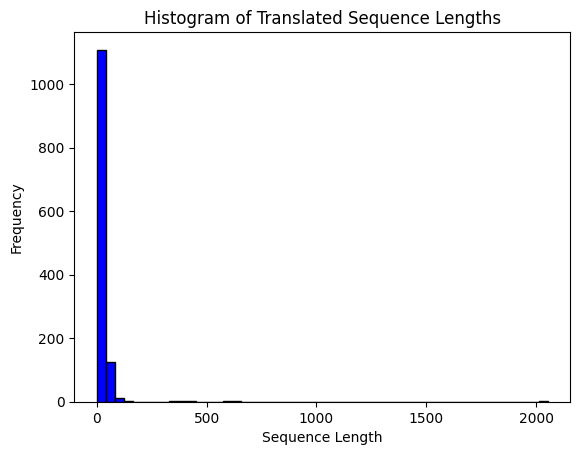

Number of sequences longer than 100 amino acids: 11


In [13]:
#create a histogram of the lengths of the translated sequences
import matplotlib.pyplot as plt

with open(sixpack_output, 'r') as f:
    sequences = []
    current_seq = ""
    for line in f:
        if line.startswith('>'):
            if current_seq:
                sequences.append(current_seq)
                current_seq = ""
        else:
            current_seq += line.strip()
    if current_seq:
        sequences.append(current_seq)

# Calculate the lengths of the sequences
sequence_lengths = [len(seq) for seq in sequences]

# Plot the histogram
plt.hist(sequence_lengths, bins=50, color='blue', edgecolor='black')
plt.xlabel('Sequence Length')
plt.ylabel('Frequency')
plt.title('Histogram of Translated Sequence Lengths')
plt.show()

#how many sequences are longer than 100 amino acids
long_sequences = [seq for seq in sequences if len(seq) > 100]
print(f"Number of sequences longer than 100 amino acids: {len(long_sequences)}")

In [14]:
#put the longer sequences into a new fasta file
long_sequences_fasta = os.path.join(output_folder, "oberland_long_sequences.fasta")
with open(long_sequences_fasta, 'w') as f:
    for i, seq in enumerate(long_sequences):
        f.write(f">long_seq_{i}\n")
        f.write(f"{seq}\n")

In [ ]:
#set long_sequences_fasta and output_db for the next step

long_sequences_fasta = os.path.join(output_folder, "oberland_long_sequences.fasta")
output_db = f"{DATAPATH}/ebola_protfams/oberland_long_sequences/oberland_long_sequences_foldseekdb"
os.environ["long_sequences_fasta"] = long_sequences_fasta



In [16]:
%%bash


MODEL_CKPT="../checkpoints/esm3di_from_mlm/epoch_5.pt"
OUTPUT_ROOT="$DATAPATH/ebola_oberland"

fname="$(basename "$long_sequences_fasta")"
stem="${fname%.*}"
out_dir="$OUTPUT_ROOT/$stem"
mkdir -p "$out_dir"

db_name="${stem}_foldseekdb"
output_db="$out_dir/$db_name"
echo "Running foldseek database creation for $long_sequences_fasta..."


python -m esm3di.fastas2foldseekdb \
    --aa-fasta "$long_sequences_fasta" \
    --model-ckpt "$MODEL_CKPT" \
    --output-db "$output_db" \
    --keep-fastas

Running foldseek database creation for /home/dmoi/projects/ESM3di/ebola_data/ebola_data/sixpack_results/oberland_long_sequences.fasta...
Checking for FoldSeek installation...
✓ FoldSeek found

Running ESM inference on /home/dmoi/projects/ESM3di/ebola_data/ebola_data/sixpack_results/oberland_long_sequences.fasta...
Using model: ../checkpoints/esm3di_from_mlm/epoch_5.pt
Device: cuda
Loading model configuration from checkpoint...
Using 2 GPU(s) for inference on 11 sequences


Multi-GPU inference:   0%|          | 0/2 [00:09<?, ?GPU/s]


Falling back to single-GPU inference...
Using single GPU: cuda
Initializing ESM3DiModel with Synthyra/ESMplusplus_small...

Loading model: Synthyra/ESMplusplus_small
Attention backend: config='sdpa' -> resolved='sdpa'


Some weights of ESMplusplusForTokenClassification were not initialized from the model checkpoint at Synthyra/ESMplusplus_small and are newly initialized: ['classifier.0.bias', 'classifier.0.weight', 'classifier.2.bias', 'classifier.2.weight', 'classifier.3.bias', 'classifier.3.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


✓ Base model loaded (TokenClassification)

Auto-discovering LoRA target modules...
Discovering LoRA target modules...
Discovered target modules: ['classifier.0', 'classifier.3', 'embed', 'sequence_head.0', 'sequence_head.3', 'transformer.blocks.0.attn.layernorm_qkv.1', 'transformer.blocks.0.attn.out_proj', 'transformer.blocks.0.ffn.1', 'transformer.blocks.0.ffn.3', 'transformer.blocks.1.attn.layernorm_qkv.1', 'transformer.blocks.1.attn.out_proj', 'transformer.blocks.1.ffn.1', 'transformer.blocks.1.ffn.3', 'transformer.blocks.10.attn.layernorm_qkv.1', 'transformer.blocks.10.attn.out_proj', 'transformer.blocks.10.ffn.1', 'transformer.blocks.10.ffn.3', 'transformer.blocks.11.attn.layernorm_qkv.1', 'transformer.blocks.11.attn.out_proj', 'transformer.blocks.11.ffn.1', 'transformer.blocks.11.ffn.3', 'transformer.blocks.12.attn.layernorm_qkv.1', 'transformer.blocks.12.attn.out_proj', 'transformer.blocks.12.ffn.1', 'transformer.blocks.12.ffn.3', 'transformer.blocks.13.attn.layernorm_qkv.1', 't

Asking to truncate to max_length but no maximum length is provided and the model has no predefined maximum length. Default to no truncation.


Processed 11/11 sequences
Writing predictions to: /home/dmoi/projects/ESM3di/ebola_data/ebola_data/ebola_oberland/oberland_long_sequences/oberland_long_sequences_foldseekdb_3di.fasta
✓ Prediction complete! 11 sequences written to /home/dmoi/projects/ESM3di/ebola_data/ebola_data/ebola_oberland/oberland_long_sequences/oberland_long_sequences_foldseekdb_3di.fasta
✓ FASTA files ready

Creating FoldSeek database: /home/dmoi/projects/ESM3di/ebola_data/ebola_data/ebola_oberland/oberland_long_sequences/oberland_long_sequences_foldseekdb
Finished writing Foldseek database to /home/dmoi/projects/ESM3di/ebola_data/ebola_data/ebola_oberland/oberland_long_sequences/oberland_long_sequences_foldseekdb
Total sequences: 11
Pep file: /home/dmoi/projects/ESM3di/ebola_data/ebola_data/ebola_oberland/oberland_long_sequences/oberland_long_sequences_foldseekdb, size: 5072 bytes
TDI file: /home/dmoi/projects/ESM3di/ebola_data/ebola_data/ebola_oberland/oberland_long_sequences/oberland_long_sequences_foldseekdb_

In [24]:
#search against the foldseek databases we made to annotate the unknown ebola proteome
import glob

def run_foldseek( querydb, targetdb, output_folder, foldseekpath = 'foldseek' , maxseqs = 3000):
	'''
	run foldseek search and createtsv
	
	parameters
	----------
	querydb : str
		path to foldseek query database
	targetdb : str 
		path to foldseek target database
	output_folder : str 
		path to output folder
	maxseqs : int   
		maximum number of sequences to compare to

	'''
	if not os.path.exists(output_folder):
		os.makedirs(output_folder)
	

	target_name = os.path.basename(targetdb)
	cmd = f"{foldseekpath} easy-search {querydb} {targetdb} {output_folder}/{target_name}_search.csv tmp --format-output 'query,target,fident,alnlen,mismatch,gapopen,qstart,qend,tstart,tend,evalue,bits' " 
	subprocess.run(cmd, shell=True, check=True)
	return os.path.join(output_folder, f"{target_name}_search.csv")

querydb = '/home/dmoi/projects/ESM3di/ebola_data/ebola_data/ebola_oberland/oberland_long_sequences/oberland_long_sequences_foldseekdb'

protfam_folders = glob.glob(f"{DATAPATH}/ebola_protfams/*")
for folder in protfam_folders:
	db_files = glob.glob(f"{folder}/*.index")
	if len(db_files) == 0:
		print(f"No .index files found in {folder}. Skipping.")
		continue

	db_path = db_files[0].replace('.index', '')  # Assuming there's only one .index file per folder
	db_path = db_path.replace('_h', '')  # Ensure the path uses forward slashes
	output_folder = os.path.join(folder, "foldseek_search_results_oberland")
	print(f"Running foldseek search for {db_path}...")
	run_foldseek(querydb=querydb, targetdb=db_path, output_folder=output_folder)
	print(f"Search results saved in {output_folder}.")
    

Running foldseek search for /home/dmoi/projects/ESM3di/ebola_data/ebola_data/ebola_protfams/Ebola_GP/Ebola_GP_foldseekdb...
Create directory tmp
easy-search /home/dmoi/projects/ESM3di/ebola_data/ebola_data/ebola_oberland/oberland_long_sequences/oberland_long_sequences_foldseekdb /home/dmoi/projects/ESM3di/ebola_data/ebola_data/ebola_protfams/Ebola_GP/Ebola_GP_foldseekdb /home/dmoi/projects/ESM3di/ebola_data/ebola_data/ebola_protfams/Ebola_GP/foldseek_search_results_oberland/Ebola_GP_foldseekdb_search.csv tmp --format-output query,target,fident,alnlen,mismatch,gapopen,qstart,qend,tstart,tend,evalue,bits 

MMseqs Version:                    	10.941cd33
Seq. id. threshold                 	0
Coverage threshold                 	0
Coverage mode                      	0
Max reject                         	2147483647
Max accept                         	2147483647
Add backtrace                      	false
TMscore threshold                  	0
TMscore threshold mode             	0
TMalign hit ord

In [46]:
#read off all of the results and make a summary table of the best hits for each query sequence
rescolumns = 'query,target,fident,alnlen,mismatch,gapopen,qstart,qend,tstart,tend,evalue,bits'.split(',')
resfiles = glob.glob(f"{DATAPATH}/ebola_protfams/*/foldseek_search_results_oberland/*.csv")
import pandas as pd

all_results = []
for resfile in resfiles:
    df = pd.read_table(resfile, names=rescolumns, header=None)
    df['source_db'] = os.path.basename(resfile).replace('_search.csv', '')
    all_results.append(df)
all_results_df = pd.concat(all_results, ignore_index=True )
print(f"Total number of hits: {len(all_results_df)}")


Total number of hits: 8026


In [47]:
all_results_df
#drop evalues greater than 1e-5 and keep the best hit for each query sequence
all_results_df = all_results_df[all_results_df['evalue'] < 1e-5]
#get top 10 for each query sequence
best_hits_df = all_results_df.sort_values('evalue').groupby('query').head(10).reset_index(drop=True)
print(f"Number of best hits after filtering: {len(best_hits_df)}")

Number of best hits after filtering: 22


In [48]:
print("Best hits summary:")
print(best_hits_df)

Best hits summary:
         query          target  fident  alnlen  mismatch  gapopen  qstart  \
0   long_seq_5      QGM12360.2   1.000     618         0        0       5   
1   long_seq_5      QGM12360.2   1.000     618         0        0       5   
2   long_seq_5  YP_010800198.1   1.000     618         0        0       5   
3   long_seq_7      AGB56682.1   0.202    2063      1613        0      31   
4   long_seq_7      AAA79970.1   0.200    2063      1617        0      31   
5   long_seq_7      AAA79970.1   0.200    2063      1617        0      31   
6   long_seq_7      WEY07143.1   0.199    2063      1619        0      31   
7   long_seq_7      AGL50931.1   0.197    2063      1623        0      31   
8   long_seq_7      AGL50931.1   0.197    2063      1623        0      31   
9   long_seq_7      ACR33194.1   0.200    2063      1617        0      31   
10  long_seq_7      ACR33194.1   0.200    2063      1617        0      31   
11  long_seq_7      WEY06666.1   0.201    2073      1611 

In [50]:
outdir = f"{DATAPATH}/oberland_results"
if not os.path.exists(outdir):
    os.makedirs(outdir)
output_file = f"{DATAPATH}/oberland_results/best_hits_summary.csv"
best_hits_df.to_csv(output_file, index=False)
print(f"Best hits summary saved to {output_file}")

Best hits summary saved to /home/dmoi/projects/ESM3di/ebola_data/ebola_data/oberland_results/best_hits_summary.csv


In [ ]:
#add the long sequences to the original ebola proteome fasta files and save as a new fasta file. we should add each sequence to its appropriate family fasta file if it has a hit, otherwise we can put it in a separate fasta file for unknown sequences. we can use the best_hits_df to determine which family each long sequence belongs to.

for fam in best_hits_df['source_db'].unique():
	fam_df = best_hits_df[best_hits_df['source_db'] == fam]
	fam_fasta_file = f"{DATAPATH}/ebola_protfams/{fam}/{fam}.fasta"
	if not os.path.exists(fam_fasta_file):
		print(f"Family fasta file {fam_fasta_file} does not exist. Skipping.")
		continue

	# Read the original family fasta
	with open(fam_fasta_file, 'r') as f:
		original_fasta = f.read()

	# Append the long sequences that belong to this family
	with open(f"{DATAPATH}/oberland_results/{fam}_augmented.fasta", 'w') as f:
		f.write(original_fasta)
		for query in fam_df['query']:
			seq_id = query.split('|')[0]  # Assuming the query format is like ">long_seq_0|..."
			seq = next((s for s in long_sequences if s.startswith(seq_id)), None)
			if seq:
				f.write(f">{seq_id}\n{seq}\n")

In [ ]:
#let's add these long sequences to the original ebola proteome fasta files and save as a new fasta file. we should add each sequence to its appropriate family fasta file if it has a hit, otherwise we can put it in a separate fasta file for unknown sequences. we can use the best_hits_df to determine which family each long sequence belongs to.

